In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [26]:
# load dataset
df = pd.read_csv("StudentsPerformance.csv")

In [27]:
# Explore & clean data
# Dataset shape (rows, columns)
print("Shape of dataset:", df.shape)

Shape of dataset: (1000, 8)


In [28]:
# Data types of all columns
print("\nData Types:")
print(df.dtypes)



Data Types:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


In [29]:
# Missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [30]:
# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())


Total Missing Values: 0


In [31]:
# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [32]:
# Statistical summary
print(df.describe())

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [33]:
# Analysis Questions
# Create final grade as average of Math, Reading, and Writing
df['final_grade'] = (df['math score'] +  df['reading score'] + df['writing score']) / 3

# 1. Average Final Grade
print("Average Final Grade:", df['final_grade'].mean())

Average Final Grade: 67.77066666666666


In [34]:
# 2. How many students scored above 15?
print("Students scoring above 15:",
      (df['final_grade'] > 15).sum())

Students scoring above 15: 999


In [35]:
# 4. Which gender performs better on average?
gender_avg = df.groupby('gender')['final_grade'].mean()

print("\nAverage Performance by Gender:")
print(gender_avg)

print("\nBest Performing Gender:",
      gender_avg.idxmax())



Average Performance by Gender:
gender
female    69.569498
male      65.837483
Name: final_grade, dtype: float64

Best Performing Gender: female


In [36]:
# 3. Is study time correlated with performance?
df['average_score'] = ( df['math score'] +df['reading score'] + df['writing score']) / 3

# correlation (reading vs overall performance)
print("Correlation between Reading Score and Overall Performance:",
      df['reading score'].corr(df['average_score']))




Correlation between Reading Score and Overall Performance: 0.9703306887176951


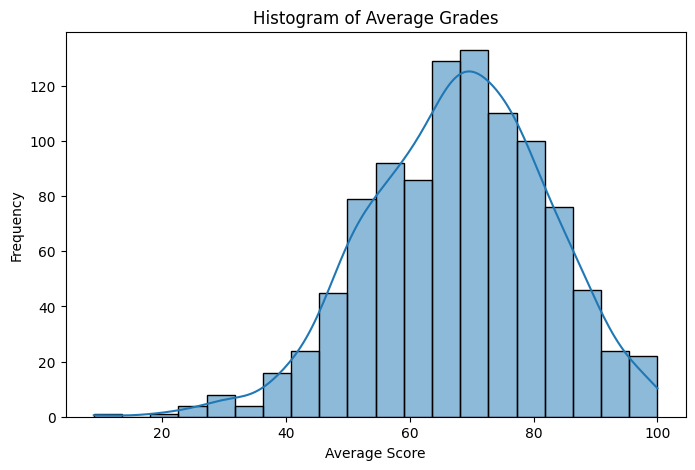

In [37]:
# Visualizations
# 1. Histogram of grades.

plt.figure(figsize=(8,5))
sns.histplot(df['average_score'], bins=20, kde=True)
plt.title("Histogram of Average Grades")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()

## 📊 Histogram: Distribution of Average Scores

### 📌 Explanation:
We use a histogram to show how student average scores are distributed.

### 🧠 Insight:
This helps us understand the most common score range among students.

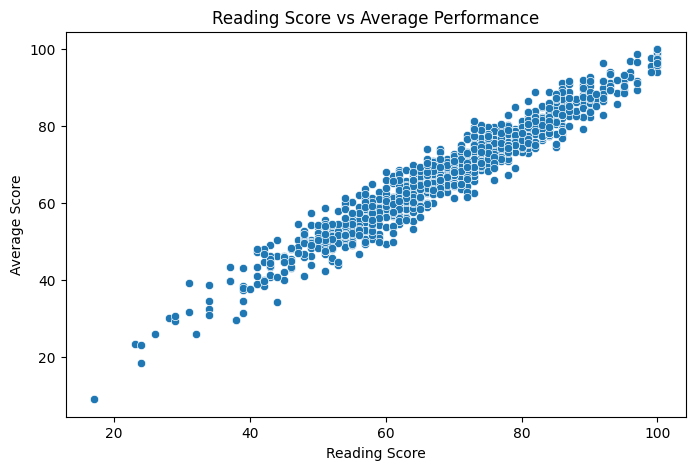

In [38]:
 #  2.Scatterplot : study time vs grade
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['reading score'], y=df['average_score'])
plt.title("Reading Score vs Average Performance")
plt.xlabel("Reading Score")
plt.ylabel("Average Score")
plt.show()

## 📈 Scatter Plot: Reading Score vs Average Performance

### 📌 Explanation:
We use a scatter plot to show the relationship between reading score and average performance.

### 🧠 Insight:
This helps us understand how reading score is related to overall student performance.

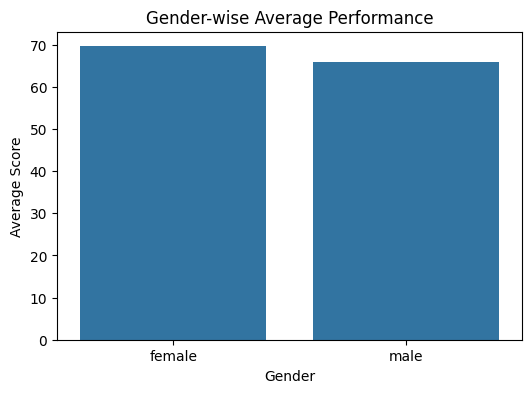

In [ ]:
#  3.Bar Chart: Male vs Female Performance
gender_avg = df.groupby('gender')['average_score'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=gender_avg.index, y=gender_avg.values)
plt.title("Gender-wise Average Performance")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

## 📊 Bar Chart: Male vs Female Average Score

### 📌 Explanation:
We are comparing the average scores of male and female students using a bar chart.

### 🧠 Insight:
This helps us understand which gender performs better on average.